In [1]:
# =========================
# 0. Install XAI Libraries
# =========================
!pip install lime shap -q

print("✅ XAI libraries installed!")

✅ XAI libraries installed!


In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, 
                                      Bidirectional, BatchNormalization, 
                                      GlobalMaxPooling1D, Concatenate, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# XAI
import shap
from lime.lime_text import LimeTextExplainer

print("✅ All imports loaded!")

✅ All imports loaded!


In [3]:
# =========================
# 2. Load & Clean Data
# =========================
data_path = "/kaggle/input/datasets/saimulhaque/disaster/different_types_of_disaster_processed.xlsx"
data = pd.read_excel(data_path)

def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", str(text))
    text = re.sub(r"@\w+|#", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)
    return text.lower().strip()

data['clean_tweet'] = data['tweet_text'].apply(clean_text)
data = data.dropna(subset=['stage_value'])

# Encode labels
label_enc = LabelEncoder()
data['label'] = label_enc.fit_transform(data['stage_value'])
class_names = label_enc.classes_

print(f"Classes: {class_names}")
print(f"Class distribution:\n{data['stage_value'].value_counts()}")

Classes: ['1st Stage' '2nd Stage' '3rd Stage']
Class distribution:
stage_value
2nd Stage    36824
3rd Stage     3316
1st Stage     2813
Name: count, dtype: int64


In [4]:
# =========================
# 3. Train-Test Split
# =========================
X = data['clean_tweet']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before balancing:", Counter(y_train))

Before balancing: Counter({1: 29459, 2: 2653, 0: 2250})


In [5]:
# =========================
# 4. Enhanced Balancing with SMOTE + ENN
# =========================
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import CountVectorizer

# Convert text to features for SMOTE (temporary)
vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)

# Apply SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_vec, y_train)

print("After SMOTEENN:", Counter(y_train_resampled))

# Get the indices to map back to original text
# Since SMOTE creates synthetic samples, we need to work with the resampled data
# We'll use the original text for training but with balanced weights

After SMOTEENN: Counter({2: 27307, 0: 26559, 1: 7576})


In [6]:
# =========================
# 5. Better Approach: Class Weights
# =========================
# Compute class weights for imbalanced data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(5.0906666666666665), 1: np.float64(0.388811568620795), 2: np.float64(4.317376554843573)}


In [7]:
# =========================
# 6. Tokenization
# =========================
max_words = 15000  # Increased for better coverage
max_len = 120      # Increased for longer tweets

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print(f"Train shape: {X_train_pad.shape}, Test shape: {X_test_pad.shape}")

Train shape: (34362, 120), Test shape: (8591, 120)


In [8]:
# =========================
# 7. Enhanced Model Architecture
# =========================
def build_enhanced_model():
    model = Sequential()
    
    # Embedding layer with trainable embeddings
    model.add(Embedding(max_words, 128, input_length=max_len))
    
    # First BiLSTM layer with regularization
    model.add(Bidirectional(LSTM(128, return_sequences=True, 
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    # Second BiLSTM layer
    model.add(Bidirectional(LSTM(64, return_sequences=True,
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    # Global pooling to capture important features
    model.add(GlobalMaxPooling1D())
    
    # Dense layers with regularization
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Output layer
    model.add(Dense(len(class_names), activation='softmax'))
    
    # Use Adam with custom learning rate
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    
    return model

model = build_enhanced_model()
model.summary()

I0000 00:00:1784031578.990026      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784031578.996271      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# =========================
# 8. Train with Enhanced Callbacks
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

# Save best model
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3323 - loss: 2.4594
Epoch 1: val_accuracy improved from None to 0.06553, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - accuracy: 0.3320 - loss: 2.2392 - val_accuracy: 0.0655 - val_loss: 2.1441 - learning_rate: 0.0010
Epoch 2/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3775 - loss: 1.6533
Epoch 2: val_accuracy improved from 0.06553 to 0.07042, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.5005 - loss: 1.4401 - val_accuracy: 0.0704 - val_loss: 3.2985 - learning_rate: 0.0010
Epoch 3/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8357 - loss: 0.9781
Epoch 3: val_accuracy improved from 0.07042 to 0.08951, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.8391 - loss: 0.9659 - val_accuracy: 0.0895 - val_loss: 3.2436 - learning_rate: 0.0010
Epoch 4/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9054 - loss: 0.7595
Epoch 4: val_accuracy improved from 0.08951 to 0.80654, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.9119 - loss: 0.7185 - val_accuracy: 0.8065 - val_loss: 1.1212 - learning_rate: 0.0010
Epoch 5/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9377 - loss: 0.5645
Epoch 5: val_accuracy improved from 0.80654 to 0.87918, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.9434 - loss: 0.4246 - val_accuracy: 0.8916 - val_loss: 0.5905 - learning_rate: 0.0010
Epoch 7/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9578 - loss: 0.3348
Epoch 7: val_accuracy improved from 0.89163 to 0.90781, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.9528 - loss: 0.3311 - val_accuracy: 0.9078 - val_loss: 0.4618 - learning_rate: 0.0010
Epoch 8/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9625 - loss: 0.2582
Epoch 8: val_accuracy improved from 0.90781 to 0.92376, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.9619 - loss: 0.2519 - val_accuracy: 0.9238 - val_loss: 0.3988 - learning_rate: 0.0010
Epoch 9/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9699 - loss: 0.1987
Epoch 9: val_accuracy did not improve from 0.92376
537/537 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.9654 - loss: 0.2009 - val_accuracy: 0.9111 - val_loss: 0.3561 - learning_rate: 0.0010
Epoch 10/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9638 - loss: 0.1873
Epoch 10: val_accuracy improved from 0.92376 to 0.97137, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.9644 - loss: 0.1900 - val_accuracy: 0.9714 - val_loss: 0.2098 - learning_rate: 0.0010
Epoch 11/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9721 - loss: 0.1587
Epoch 11: val_accuracy did not improve from 0.97137
537/537 ━━━━━━━━━━━━━━━━━━━━ 627s 1s/step - accuracy: 0.9714 - loss: 0.1548 - val_accuracy: 0.9673 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 12/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9715 - loss: 0.1555
Epoch 12: val_accuracy improved from 0.97137 to 0.97160, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
537/537 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.9694 - loss: 0.1556 - val_accuracy: 0.9716 - val_loss: 0.1973 - learning_rate: 0.0010
Epoch 13/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9744 - loss: 0.1326
Epoch 13: val_accuracy did not improve from 0.97160
537/537 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.9728 - loss: 0.1338 - val_accuracy: 0.9006 - val_loss: 0.3578 - learning_rate: 0.0010
Epoch 14/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9702 - loss: 0.1443
Epoch 14: val_accuracy did not improve from 0.97160
537/537 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - accuracy: 0.9694 - loss: 0.1570 - val_accuracy: 0.9027 - val_loss: 0.9167 - learning_rate: 0.0010
Epoch 15/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9588 - loss: 0.2073
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_accuracy did not improve from 0.97160
537/537 ━━━━━━━━━━━━━━━━━━━━ 699

269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 210ms/step

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   1st Stage       0.90      0.89      0.89       563
   2nd Stage       0.98      0.99      0.98      7365
   3rd Stage       0.97      0.84      0.90       663

    accuracy                           0.97      8591
   macro avg       0.95      0.91      0.92      8591
weighted avg       0.97      0.97      0.97      8591



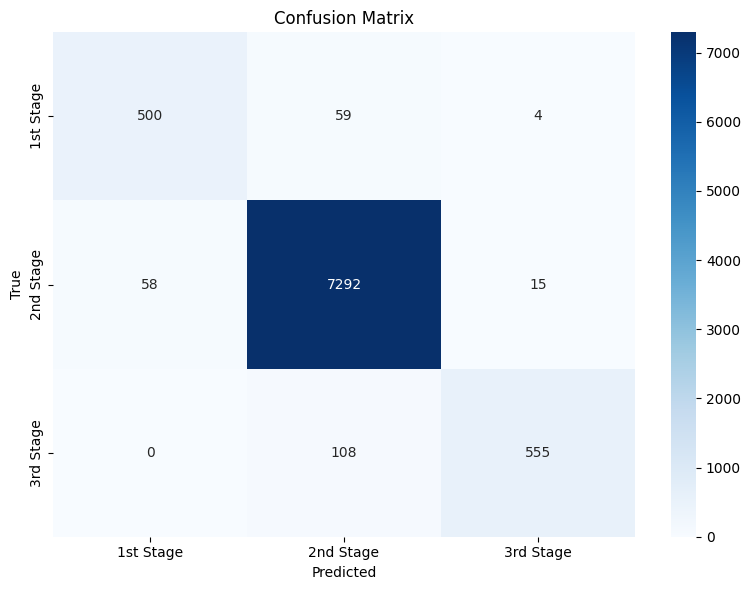

In [10]:
# =========================
# 9. Load Best Model & Evaluate
# =========================
from tensorflow.keras.models import load_model

# Load best model
best_model = load_model('best_model.h5')

# Predict
y_pred = best_model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

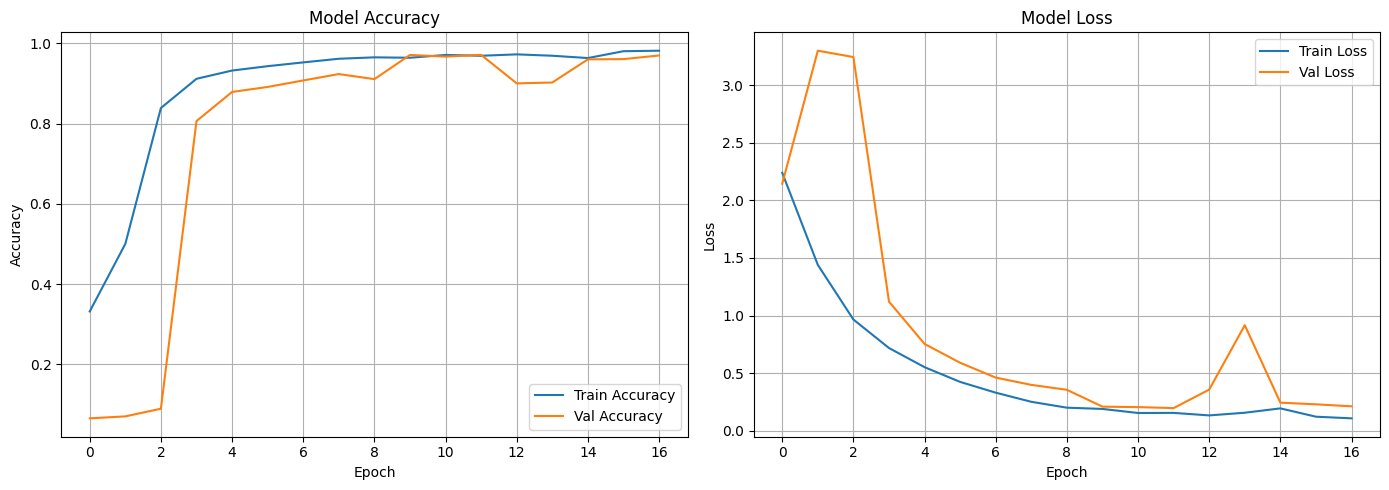

In [11]:
# =========================
# 10. Training History Plots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# =========================
# 11. Prediction Helper Functions
# =========================
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    seq = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    return best_model.predict(padded, verbose=0)

def predict(texts):
    return np.argmax(predict_proba(texts), axis=1)

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [13]:
# =========================
# 12. XAI: LIME Explanations
# =========================
print("\n" + "="*70)
print("🔍 LIME EXPLANATIONS")
print("="*70)

lime_explainer = LimeTextExplainer(class_names=class_names)

# Explain sample predictions
for idx in range(5):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    
    print(f"\n🔹 Example {idx+1}: True={true_label}, Pred={pred_label}")
    print(f"   Text: {text[:150]}...")
    
    try:
        exp = lime_explainer.explain_instance(
            text,
            predict_proba,
            num_features=10,
            num_samples=500,
            top_labels=3
        )
        
        print("   📝 Top words:")
        for word, weight in exp.as_list(label=y_pred_classes[idx])[:8]:
            sign = "✅" if weight > 0 else "❌"
            print(f"      {sign} '{word}': {weight:.4f}")
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
    
    print("-" * 50)


🔍 LIME EXPLANATIONS

🔹 Example 1: True=2nd Stage, Pred=2nd Stage
   Text: baby stuffed in bag hoisted from flood australias powerful storms led to an amazing rescue of two women and a...
   📝 Top words:
      ❌ 'hoisted': -0.0017
      ✅ 'baby': 0.0014
      ❌ 'led': -0.0013
      ❌ 'from': -0.0010
      ✅ 'storms': 0.0010
      ❌ 'bag': -0.0009
      ✅ 'women': 0.0009
      ❌ 'stuffed': -0.0008
--------------------------------------------------

🔹 Example 2: True=2nd Stage, Pred=2nd Stage
   Text: rt  an explosion at a  plant in west texas was felt for over  miles away...
   📝 Top words:
      ❌ 'away': -0.0025
      ✅ 'felt': 0.0023
      ✅ 'over': 0.0021
      ❌ 'rt': -0.0017
      ✅ 'miles': 0.0015
      ✅ 'an': 0.0014
      ✅ 'a': 0.0013
      ❌ 'in': -0.0012
--------------------------------------------------

🔹 Example 3: True=2nd Stage, Pred=2nd Stage
   Text: video shows moment of train crash that killed at least  in spain...
   📝 Top words:
      ❌ 'moment': -0.0141
      ❌ '


📊 Generating LIME Multi-Example Grid


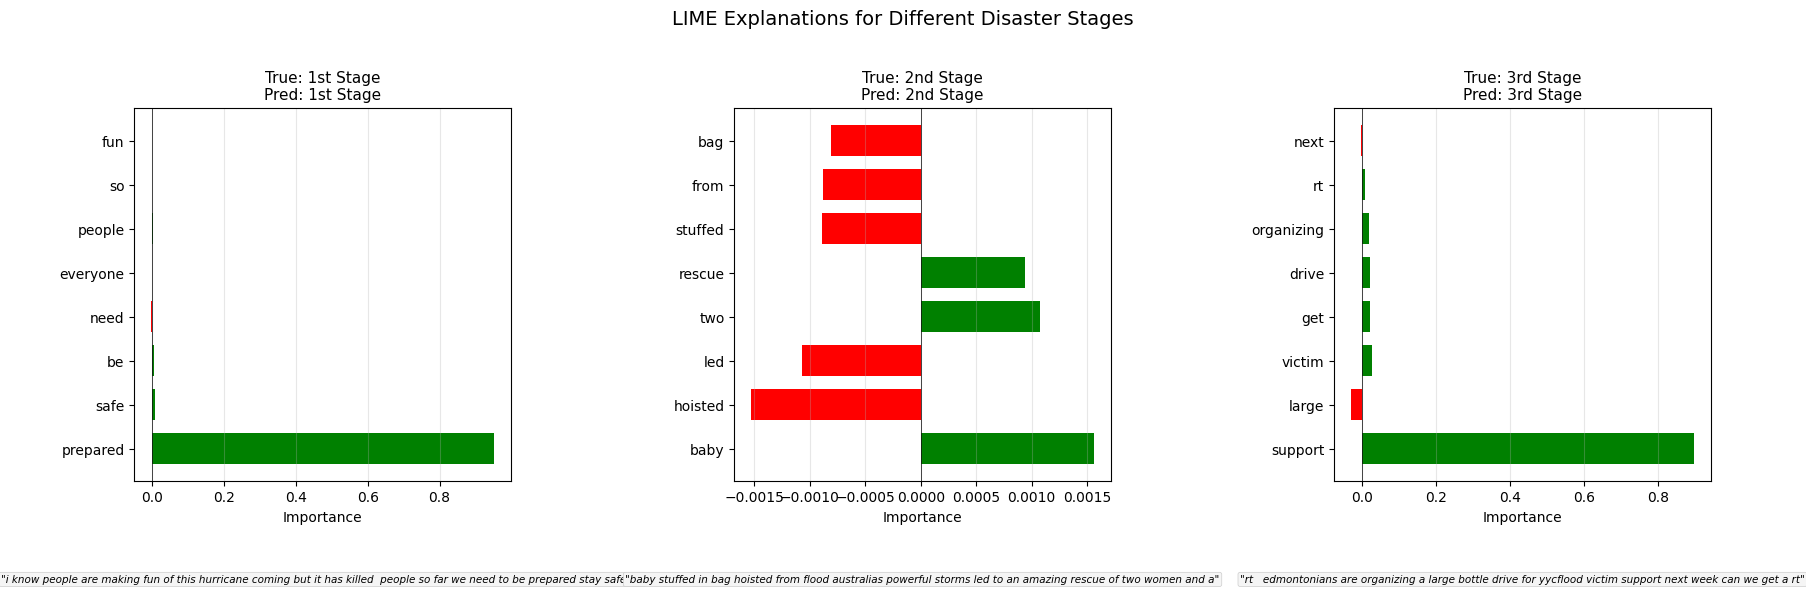

✅ Saved: lime_multi_stages.png


In [14]:
# =========================
# 13. XAI: LIME Multi-Example Grid
# =========================
print("\n📊 Generating LIME Multi-Example Grid")

# Select examples from different classes
example_indices = []
for class_idx in range(len(class_names)):
    indices = np.where(y_test == class_idx)[0]
    if len(indices) > 0:
        example_indices.append(indices[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(example_indices[:3]):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    
    exp = lime_explainer.explain_instance(
        text,
        predict_proba,
        num_features=8,
        num_samples=300,
        top_labels=3
    )
    
    exp_list = exp.as_list(label=y_pred_classes[idx])
    words = [item[0] for item in exp_list[:8]]
    weights = [item[1] for item in exp_list[:8]]
    
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    axes[i].barh(words, weights, color=colors, height=0.7)
    axes[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[i].set_xlabel('Importance', fontsize=10)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='x')
    
    # Add tweet text
    display_text = text[:120] + "..." if len(text) > 120 else text
    axes[i].text(0.5, -0.25, f'"{display_text}"', 
                transform=axes[i].transAxes,
                fontsize=7.5, ha='center', va='top', wrap=True,
                style='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5', 
                         edgecolor='#cccccc', linewidth=0.5))

plt.suptitle('LIME Explanations for Different Disaster Stages', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lime_multi_stages.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: lime_multi_stages.png")


📊 SHAP Summary Plot
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step


<Figure size 1200x600 with 0 Axes>

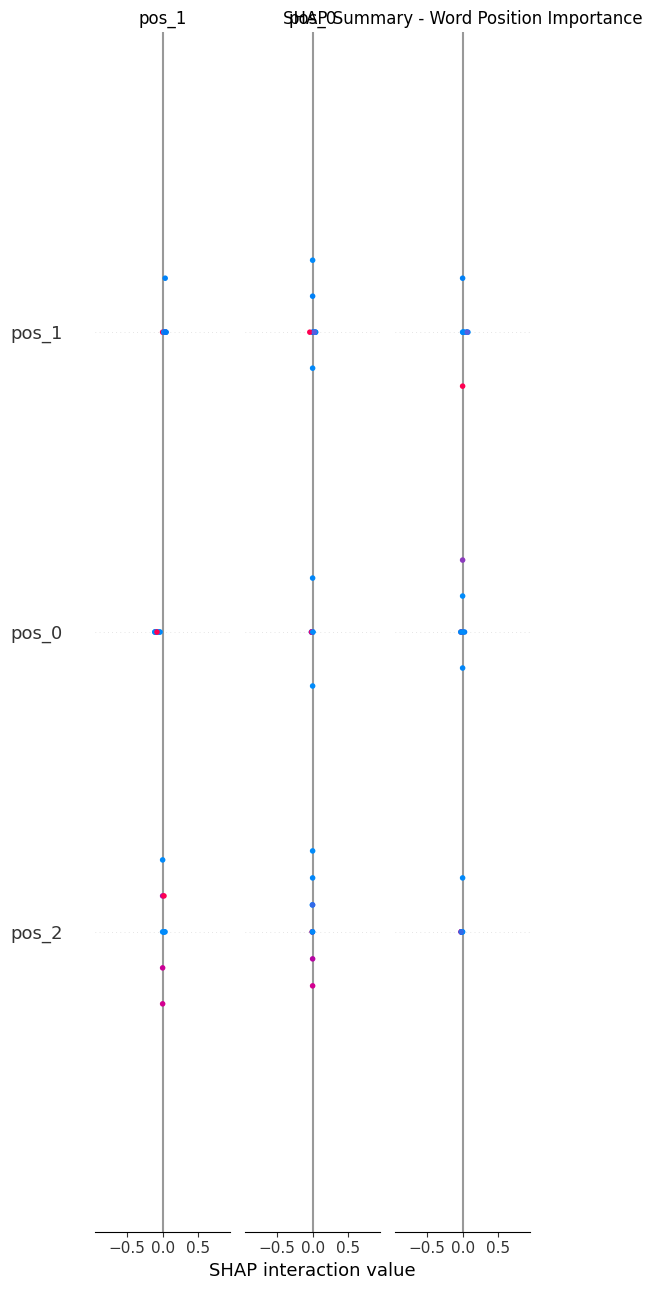

✅ Saved: shap_summary_stages.png


In [15]:
# =========================
# 14. XAI: SHAP Summary Plot
# =========================
print("\n📊 SHAP Summary Plot")

try:
    # Use background sample
    background = X_train_pad[np.random.choice(len(X_train_pad), 50, replace=False)]
    explainer_shap = shap.KernelExplainer(best_model.predict, background)
    
    # Explain sample
    shap_values = explainer_shap.shap_values(X_test_pad[:10], nsamples=50)
    
    if isinstance(shap_values, list):
        shap_values_avg = np.mean(np.array(shap_values), axis=0)
    else:
        shap_values_avg = shap_values
    
    feature_names = [f'pos_{i}' for i in range(max_len)]
    
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values_avg, X_test_pad[:10], 
                     feature_names=feature_names, show=False, max_display=15)
    plt.title("SHAP Summary - Word Position Importance")
    plt.tight_layout()
    plt.savefig('shap_summary_stages.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: shap_summary_stages.png")
    
except Exception as e:
    print(f"⚠️ SHAP failed: {e}")

In [16]:
# =========================
# 15. XAI: Top Words Per Stage
# =========================
print("\n📊 Top Words per Disaster Stage")

weights = best_model.layers[-1].get_weights()[0]
reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}

for class_idx, class_name in enumerate(class_names):
    class_weights = weights[class_idx]
    top_indices = np.argsort(class_weights)[-10:][::-1]
    
    print(f"\n🔹 {class_name}:")
    words = []
    for idx in top_indices[:5]:
        word = reverse_word_map.get(idx, f'<OOV>')
        words.append(f"{word} ({class_weights[idx]:.3f})")
    print(f"   {', '.join(words)}")


📊 Top Words per Disaster Stage

🔹 1st Stage:
   <OOV> (0.010), <OOV> (-0.158), rt (-0.169)

🔹 2nd Stage:
   <OOV> (0.089), rt (-0.074), <OOV> (-0.116)

🔹 3rd Stage:
   <OOV> (0.101), rt (0.100), <OOV> (-0.090)



📊 Misclassified Examples Analysis
Found 244 misclassifications


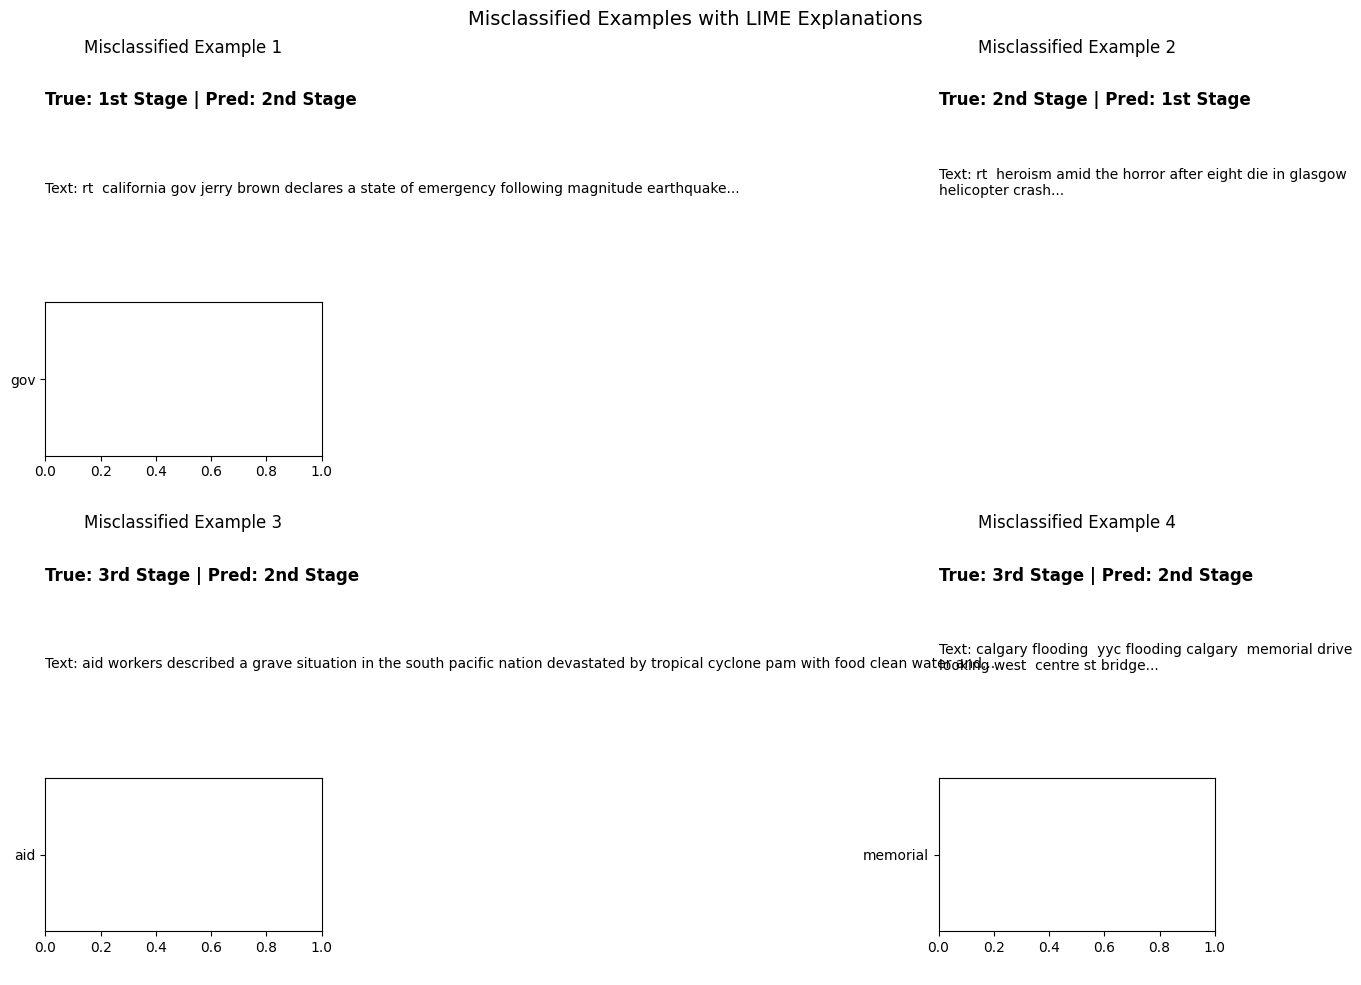

✅ Saved: misclassified_stages.png


In [17]:
# =========================
# 16. XAI: Misclassified Examples
# =========================
print("\n📊 Misclassified Examples Analysis")

misclassified = np.where(y_test != y_pred_classes)[0]

if len(misclassified) > 0:
    print(f"Found {len(misclassified)} misclassifications")
    
    # Show examples in a grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(misclassified[:4]):
        true_label = class_names[y_test.iloc[idx]]
        pred_label = class_names[y_pred_classes[idx]]
        text = X_test.iloc[idx]
        
        axes[i].text(0.1, 0.9, f'True: {true_label} | Pred: {pred_label}', 
                    fontsize=12, weight='bold', transform=axes[i].transAxes)
        axes[i].text(0.1, 0.7, f'Text: {text[:150]}...', fontsize=10, 
                    wrap=True, transform=axes[i].transAxes)
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(0, 1)
        axes[i].axis('off')
        axes[i].set_title(f'Misclassified Example {i+1}', fontsize=12)
        
        # Add LIME explanation
        try:
            exp = lime_explainer.explain_instance(
                text, predict_proba,
                num_features=5, num_samples=200
            )
            exp_list = exp.as_list(label=y_pred_classes[idx])
            words = [item[0] for item in exp_list[:5]]
            weights = [item[1] for item in exp_list[:5]]
            
            ax2 = axes[i].inset_axes([0.1, 0.1, 0.8, 0.35])
            colors = ['green' if w > 0 else 'red' for w in weights]
            ax2.barh(words, weights, color=colors)
            ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            ax2.set_xlabel('Importance', fontsize=8)
            ax2.tick_params(labelsize=8)
        except:
            pass
    
    plt.suptitle('Misclassified Examples with LIME Explanations', fontsize=14)
    plt.tight_layout()
    plt.savefig('misclassified_stages.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: misclassified_stages.png")
else:
    print("✅ No misclassifications!")

In [18]:
# =========================
# 17. Summary
# =========================
print("\n" + "="*70)
print("📋 MODEL PERFORMANCE SUMMARY")
print("="*70)

# Calculate per-class F1 scores
from sklearn.metrics import f1_score

f1_scores = f1_score(y_test, y_pred_classes, average=None)

for i, class_name in enumerate(class_names):
    print(f"   {class_name}: F1 = {f1_scores[i]:.4f}")

print(f"\n   Macro F1: {np.mean(f1_scores):.4f}")
print(f"   Weighted F1: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}")

print("\n📁 Images saved:")
print("   - lime_multi_stages.png")
print("   - shap_summary_stages.png")
print("   - misclassified_stages.png")
print("="*70)


📋 MODEL PERFORMANCE SUMMARY
   1st Stage: F1 = 0.8921
   2nd Stage: F1 = 0.9838
   3rd Stage: F1 = 0.8973

   Macro F1: 0.9244
   Weighted F1: 0.9711

📁 Images saved:
   - lime_multi_stages.png
   - shap_summary_stages.png
   - misclassified_stages.png
